## **Conflict Panel Window Generator**

In this notebook, we are going to generate a cutted panel dataset to feed csdid. For that we are going to work with a monthly conflict panel dataset that contains information about fatalities and treatment status (peace agreement signed or not) at the conflict level.

Steps:

1. Load the panel dataset already generated at conflict level with monthly frequency.
2. Generate some columns needed for the <code>WindowGenerator</code> class.
3. Instantiate the <code>WindowGenerator</code> class with the desired parameters to generate a balanced panel dataset.
4. Export the windows dataset to a csv file for later use in the causal effect estimation with <code>csdid</code>.

Units of this panel are the <code>conflict_id</code> and time in months (<code>year_mo</code>).

In [32]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from window_generator import WindowGenerator
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../')))

In [33]:
df = pd.read_csv('../../../../data/output/conflict_level/conflict_panel.csv')

/var/folders/fz/1mp_qssx1z546qc9z63nq3rm0000gn/T/ipykernel_10455/4176885216.py:1: DtypeWarning: Columns (84,85,87,88,91,92,93,96,97,98,99,100,101,102,103,109) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../../../../data/output/conflict_level/conflict_panel.csv')


In [34]:
treatment_vars = ['ceasfire_agreements_mentions', 'treated_ceasfire_agreements_mentions',
                  'agreement_no_ceasefire','treated_agreements_no_ceasefire', 'agreement_no_ceasefire_mentions_agreement_6m',
                  'comp_agreement_no_ceasefire','treated_comp_agreements_no_ceasefire', 'comp_agreement_no_ceasefire_mentions_agreement_6m',
                  'subs_agreement_no_ceasefire','treated_subs_agreements_no_ceasefire', 'subs_agreement_no_ceasefire_mentions_agreement_6m']

info_vars = ['ceprov', 'cegen', 'ele', 'eleccomm',
             'hrni','hrii','hriimon','hriibod',
             'med', 'medgov', 'medsubs',
             'medlog', 'civso', 'hrmob', 'tjmech', 'tjmis']

commit_vars = ['polps', 'ppsex', 'ppsoro', 'ppsvet','ppsaut', 'ppsothpr','ppsint',
               'terps', 'tpssub', 'tpsloc', 'tpsaut','tpsoth',
               'eps', 'epsres', 'epsfis', 'epsoth',
               'mps', 'mpsme', 'mpsjt', 'mpspro',
               'ssrpol', 'ssrarm', 'ssrddr', 'ddrdemil','ddrprog','ssrgua',
               'impk', 'ime', 'imun', 'imoth', 'imref',
               'pol', 'polnewind', 'polnewtemp', 'ele','eleccomm', 'polpar']

cost_vars = ['ssrddr', 'ddrprog', 'ddrdemil', 'ddrprog',
              'tjcou', 'tjamban', 'tjvet', 'tjrep', 'tjvic',
             'prot', 'protciv', 'protgrp']


check_balances_vars = ['hrni', 'hrii', 'hrbor', 'hrdem', 'hrtrinc', 'juscr', 'polpar',
                       'pubad']
features_cluster_columns = list(set(info_vars + commit_vars + cost_vars + check_balances_vars))
df = df[['conflict_id', 'year_mo_numeric', 'year_mo','log_best','best', 
        'treated_agreement', 'agreement','first_agreement_date',  
        'treated_comp_agreement','comp_agreement', 'first_comp_agreement_date',
        'subs_agreement', 'treated_subs_agreement', 'first_subs_agreement_date',
        'cea_agreement', 'treated_cea_agreement', 'first_cea_agreement_date',
        'cea_ceas_agreement', 'treated_cea_ceas_agreement', 'first_cea_ceas_agreement_date',
        'cea_rel_agreement', 'treated_cea_rel_agreement', 'first_cea_rel_agreement_date',
        'cea_ceamix_agreement', 'treated_cea_ceamix_agreement', 'first_cea_ceamix_agreement_date',
        'ce',
        'isocode_main', 'isocode_main_num', 'region_main_num', 'region_main', 
        'conflict_age', 'duration_months', 'active_conflict_age', 'active_duration_months', 
        'conflict_age_less_6m', 'conflict_age_less_12m', 'conflict_age_less_18m', 'conflict_age_less_24m', 'conflict_age_less_30m', 
        'start_date_numeric', 'start_date', 'real_observation', 'gdp_pc_current_usd', 'population_total',
        ]+ treatment_vars+ features_cluster_columns]


### **Define treatment variables**

In [35]:
# Time period factorization
# ================================================================================
df['year_mo'] = pd.to_datetime(df['year_mo'])
df['conflict_id_t'] = df.groupby('conflict_id').year_mo.transform(lambda x: pd.factorize(x, sort=True)[0])
df = df.sort_values(['conflict_id', 'year_mo'])  # make sure data is sorted correctly
#define matching columns with lagged values to match on t-1 values
df['log_best_lag1'] = df.groupby('conflict_id')['log_best'].shift(1)
df['gdp_pc_current_usd_lag1'] = df.groupby('conflict_id')['gdp_pc_current_usd'].shift(1)
df 

,conflict_id,year_mo_numeric,year_mo,log_best,best,treated_agreement,agreement,first_agreement_date,treated_comp_agreement,comp_agreement,...,pol,civso,ssrpol,medlog,tjamban,tjrep,tjvet,conflict_id_t,log_best_lag1,gdp_pc_current_usd_lag1
0,205,1,1989-01-01,0.000000,0.0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN
1,205,2,1989-02-01,0.000000,0.0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0.0,2124.972148
2,205,3,1989-03-01,0.000000,0.0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,0.0,2124.972148
3,205,4,1989-04-01,0.000000,0.0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3,0.0,2124.972148
4,205,5,1989-05-01,0.000000,0.0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,0.0,2124.972148
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86827,16379,428,2024-08-01,0.000000,0.0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,427,0.0,629.538899
86828,16379,429,2024-09-01,0.000000,0.0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,428,0.0,629.538899
86829,16379,430,2024-10-01,0.000000,0.0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,429,0.0,629.538899
86830,16379,431,2024-11-01,0.000000,0.0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,430,0.0,629.538899


## **Generate windows**

In [36]:
treatment = 'ceasfire_agreements_mentions'
frame_size   = [18, 18] # how large of a window 'frame' to sample
buffer_size_treated  = [18, 1]  # months since treatment and until treatment
buffer_size_control = [18, 18]  # months since treatment and until treatment

In [37]:
wg = WindowGenerator(dataframe = df,
                     frame_size = frame_size,
                     unit_column = 'conflict_id',
                     time_column = 'conflict_id_t',
                     treatment_column = treatment,
                     )

In [38]:
wg.generate_treatment_windows(buffer_size=buffer_size_treated)

=== Potential Windows Generation Summary ===
---> Total possible windows found: 458
---> Excluded 23 units/times due to insufficient data (frame size requirement).
---> Excluded windw_id's (unit_time): ['230_421', '233_17', '283_419', '283_426', '283_429', '289_414', '289_415', '289_416', '289_417', '289_419', '289_420', '289_421', '289_422', '289_423', '289_424', '289_426', '289_429', '309_418', '309_420', '336_14', '336_15', '426_430', '11345_424']
Generated 435 windows.
=== Windows Buffer Checking Summary ===
Generated 99 valid windows.
=== Windows Continuity Checking Summary ===
Generated 99 valid continuous windows.


In [39]:
wg.treated_windows.window_id.nunique()

99

In [40]:
matching_params = {
    'matching_columns': ['gdp_pc_current_usd_lag1'],#['log_best_lag1', 'gdp_pc_current_usd_lag1'],
    'distance_threshold': 0.2,  # normalized euclidean distance threshold
}
matching_method='knn'
wg.generate_control_windows(buffer_size=buffer_size_control, k=5, t=1, 
                            matching_method=matching_method, 
                            matching_params=matching_params)

=== Potential Windows Generation Summary ===
---> Total possible windows found: 86374
---> Excluded 7213 units/times due to insufficient data (frame size requirement).
---> Excluded windw_id's (unit_time): ['205_0', '205_1', '205_2', '205_3', '205_4', '205_5', '205_6', '205_7', '205_8', '205_9', '205_10', '205_11', '205_12', '205_13', '205_14', '205_15', '205_16', '205_17', '205_414', '205_415', '205_416', '205_417', '205_418', '205_419', '205_420', '205_421', '205_422', '205_423', '205_424', '205_425', '205_426', '205_427', '205_428', '205_429', '205_430', '205_431', '209_0', '209_1', '209_2', '209_3', '209_4', '209_5', '209_6', '209_7', '209_8', '209_9', '209_10', '209_11', '209_12', '209_13', '209_14', '209_15', '209_16', '209_17', '209_414', '209_415', '209_416', '209_417', '209_418', '209_419', '209_420', '209_421', '209_422', '209_423', '209_424', '209_425', '209_426', '209_427', '209_428', '209_429', '209_430', '209_431', '218_0', '218_1', '218_2', '218_3', '218_4', '218_5', '21

In [41]:
wg.control_windows.window_id.nunique()

465

In [42]:
df_clean = wg.combined_windows
df_clean['window_id_num'] = df_clean['window_id'].astype('category').cat.codes
df_clean

,conflict_id,year_mo_numeric,year_mo,log_best,best,treated_agreement,agreement,first_agreement_date,treated_comp_agreement,comp_agreement,...,tjvet,conflict_id_t,log_best_lag1,gdp_pc_current_usd_lag1,window_id,window_t,is_treated_window,gdp_pc_current_usd_lag1_norm,matched_treated_window_id,window_id_num
0,209,93,1996-09-01,0.000000,0.0,1,0,45,0,0,...,0.0,92,0.000000,1311.092494,209_110,-18,1,NaN,NaN,241
1,209,94,1996-10-01,1.098612,2.0,1,0,45,0,0,...,0.0,93,0.000000,1311.092494,209_110,-17,1,NaN,NaN,241
2,209,95,1996-11-01,0.000000,0.0,1,0,45,0,0,...,0.0,94,1.098612,1311.092494,209_110,-16,1,NaN,NaN,241
3,209,96,1996-12-01,0.000000,0.0,1,0,45,0,0,...,0.0,95,0.000000,1311.092494,209_110,-15,1,NaN,NaN,241
4,209,97,1997-01-01,0.000000,0.0,1,0,45,0,0,...,0.0,96,0.000000,1311.092494,209_110,-14,1,NaN,NaN,241
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20641,13219,369,2019-09-01,0.000000,0.0,0,0,0,0,0,...,0.0,368,0.000000,3619.861572,13219_354,14,0,0.065486,13306_350,54
20642,13219,370,2019-10-01,0.000000,0.0,0,0,0,0,0,...,0.0,369,0.000000,3619.861572,13219_354,15,0,0.065486,13306_350,54
20643,13219,371,2019-11-01,0.000000,0.0,0,0,0,0,0,...,0.0,370,0.000000,3619.861572,13219_354,16,0,0.065486,13306_350,54
20644,13219,372,2019-12-01,0.000000,0.0,0,0,0,0,0,...,0.0,371,0.000000,3619.861572,13219_354,17,0,0.065486,13306_350,54


### **Dessagregating by conflict intensity**

Looking at the levels of violence preagreement $window_t = [-18, 0]$, take the $median(\sum_{w_t = -18}^{0}log\_best)$ and define:

- high intensity conflicts: those with $\sum_{w_t = -18}^{0}log\_best>$  the median
- low intensity conflicts: those with $\sum_{w_t = -18}^{0}log\_best<$  the median

In [43]:
# 1 Filter only treated windows within the period -18 to 0
pre_sum = (
    df_clean[df_clean['window_t'].between(-18, 0)]
    .groupby('window_id')['log_best']
    .sum()
)
pre_sum.name = 'pre_sum_log_best'

# 2 Merge result to dataframe (constant broadcast by window_id)
df_clean = df_clean.merge(pre_sum, on='window_id', how='left')

# 3 Calculate median only for treated
median_sum = df_clean.loc[df_clean['is_treated_window'] == 1, 'pre_sum_log_best'].median()

# 4 Create intensity variable
df_clean['intensity_level'] = 'control'
mask_treated = df_clean['is_treated_window'] == 1
df_clean.loc[mask_treated & (df_clean['pre_sum_log_best'] > median_sum), 'intensity_level'] = 'high_intensity'
df_clean.loc[mask_treated & (df_clean['pre_sum_log_best'] <= median_sum), 'intensity_level'] = 'low_intensity'

df_clean.loc[df_clean['is_treated_window']==1][['conflict_id', 'year_mo', 'log_best', 'window_id','window_t', 'pre_sum_log_best', 'intensity_level']]

,conflict_id,year_mo,log_best,window_id,window_t,pre_sum_log_best,intensity_level
0,209,1996-09-01,0.000000,209_110,-18,12.019068,low_intensity
1,209,1996-10-01,1.098612,209_110,-17,12.019068,low_intensity
2,209,1996-11-01,0.000000,209_110,-16,12.019068,low_intensity
3,209,1996-12-01,0.000000,209_110,-15,12.019068,low_intensity
4,209,1997-01-01,0.000000,209_110,-14,12.019068,low_intensity
...,...,...,...,...,...,...,...
3436,13306,2019-05-01,3.349904,13306_350,14,65.971357,high_intensity
3437,13306,2019-06-01,3.488903,13306_350,15,65.971357,high_intensity
3438,13306,2019-07-01,3.504055,13306_350,16,65.971357,high_intensity
3439,13306,2019-08-01,3.238678,13306_350,17,65.971357,high_intensity


In [44]:
df_clean.loc[df_clean['is_treated_window']==0][['conflict_id', 'year_mo', 'log_best', 'window_id', 'window_t', 'is_treated_window','pre_sum_log_best', 'intensity_level']]

,conflict_id,year_mo,log_best,window_id,window_t,is_treated_window,pre_sum_log_best,intensity_level
3441,14275,1997-05-01,0.0,14275_118,-18,0,0.0,control
3442,14275,1997-06-01,0.0,14275_118,-17,0,0.0,control
3443,14275,1997-07-01,0.0,14275_118,-16,0,0.0,control
3444,14275,1997-08-01,0.0,14275_118,-15,0,0.0,control
3445,14275,1997-09-01,0.0,14275_118,-14,0,0.0,control
...,...,...,...,...,...,...,...,...
20641,13219,2019-09-01,0.0,13219_354,14,0,0.0,control
20642,13219,2019-10-01,0.0,13219_354,15,0,0.0,control
20643,13219,2019-11-01,0.0,13219_354,16,0,0.0,control
20644,13219,2019-12-01,0.0,13219_354,17,0,0.0,control


In [45]:
df_clean.loc[df_clean['intensity_level']=='low_intensity']['window_id'].nunique()

47

### **Mechanisms variables**
---


In [46]:
#A. Reduce information asymmetries
info_vars = [#'ceprov', 'cegen', 
             'ele', 'eleccomm', #Electoral & political info
             'hrni','hrii','hriimon','hriibod', #Rights monitoring bodies:
             'med', 'medgov', 'medsubs','medlog',  #Media + civil society
             'civso', # Civil Society inclusion
             'hrmob', #Mobility for observers/humanitarians
             'tjmech', 'tjmis' #Transitional-justice mechanisms that surface facts
             ] 
#B. Build commitment power (credible commitments)
commit_vars_pol = ['polps', 'ppsex', 'ppsoro', 'ppsvet','ppsaut', 'ppsothpr','ppsint', #Political power-sharing:
               'terps', 'tpssub', 'tpsloc', 'tpsaut','tpsoth', # Territorial power-sharing
               'impk', 'ime', 'imun', 'imoth', 'imref', #International guarantees /enforcement
               'pol', 'polnewind', 'polnewtemp', 'ele','eleccomm', 'polpar'] # Institutional reforms and elections

commit_vars_econ = ['eps', 'epsres', 'epsfis', 'epsoth'] #Economic power-sharing
commit_vars_mil = ['mps', 'mpsme', 'mpsjt', 'mpspro', #Military power-sharing
                   'ssrpol', 'ssrarm', 'ssrddr', 'ddrdemil','ddrprog','ssrgua']#Security sector reform

commit_vars = commit_vars_pol + commit_vars_econ + commit_vars_mil

#C. Internalize the costs of conflict
cost_vars = ['ssrddr', 'ddrprog', 'ddrdemil', 'ddrprog', #Disarmament / demobilization / de-mining
              'tjcou', 'tjamban', 'tjvet', #Accountability & rule-of-law that raise the price of defection:
              'tjrep', 'tjvic', #Reparations & victim support
             'prot', 'protciv', 'protgrp'] #Protection of civilians

#D. Constrain unchecked leaders (checks & balances)
check_balances_vars = ['hrni', 'hrii', 'hrbor', 'hrdem', 'hrtrinc', 'juscr', 'polpar',
                       'pubad']

In [47]:
df_clean['has_info_mecha'] = (df_clean[info_vars].sum(axis=1) > 0).astype(int)
df_clean['has_commit_mecha'] = (df_clean[commit_vars].sum(axis=1) > 0).astype(int)
df_clean['has_commit_pol_mecha'] = (df_clean[commit_vars_pol].sum(axis=1) > 0).astype(int)
df_clean['has_commit_econ_mecha'] = (df_clean[commit_vars_econ].sum(axis=1) > 0).astype(int)
df_clean['has_commit_mil_mecha'] = (df_clean[commit_vars_mil].sum(axis=1) > 0).astype(int)
df_clean['has_cost_mecha'] = (df_clean[cost_vars].sum(axis=1) > 0).astype(int)
df_clean['has_balancing_mecha'] = (df_clean[check_balances_vars].sum(axis=1) > 0).astype(int)



df_clean.loc[(df_clean['window_t']==0) & (df_clean['is_treated_window']==1)].groupby('has_balancing_mecha')['window_id'].nunique()

has_balancing_mecha
0    40
1    53
Name: window_id, dtype: int64

In [48]:
for col in ['has_info_mecha', 'has_commit_mecha', 'has_commit_pol_mecha', 'has_commit_econ_mecha',
            'has_commit_mil_mecha', 'has_cost_mecha', 'has_balancing_mecha']:
    
    # Identify treated windows WITH information mechanisms at t=0
    treated_info_windows = df_clean.loc[
        (df_clean['is_treated_window'] == 1) &
        (df_clean['window_t'] == 0) &
        (df_clean[col] == 1),
        'window_id'
    ].unique()

    # Assign indicator to the whole window
    df_clean['is_'+col+'_window'] = df_clean['window_id'].isin(treated_info_windows).astype(int)


In [50]:
if len(matching_params['matching_columns'])>1:
    print(f'../../../../data/output/conflict_level/windows/conflict_windows_{matching_method}_matching_{"_".join(matching_params["matching_columns"])}_{treatment}.csv')
    df_clean.to_csv(f'../../../../data/output/conflict_level/windows/conflict_windows_{matching_method}_matching_{"_".join(matching_params["matching_columns"])}_{treatment}.csv', index=False)
elif len(matching_params['matching_columns'])==1:
    print(f'../../../../data/output/conflict_level/windows/conflict_windows_{matching_method}_matching_{matching_params["matching_columns"][0]}_{treatment}.csv')
    df_clean.to_csv(f'../../../../data/output/conflict_level/windows/conflict_windows_{matching_method}_matching_{matching_params["matching_columns"][0]}_{treatment}.csv', index=False)
else:
    print(f'../../../../data/output/conflict_level/windows/conflict_windows_{matching_method}_matching_{treatment}.csv')
    df_clean.to_csv(f'../../../../data/output/conflict_level/windows/conflict_windows_{matching_method}_matching_{treatment}.csv', index=False)


../../../../data/output/conflict_level/windows/conflict_windows_knn_matching_gdp_pc_current_usd_lag1_ceasfire_agreements_mentions.csv


<Figure size 1200x600 with 0 Axes>

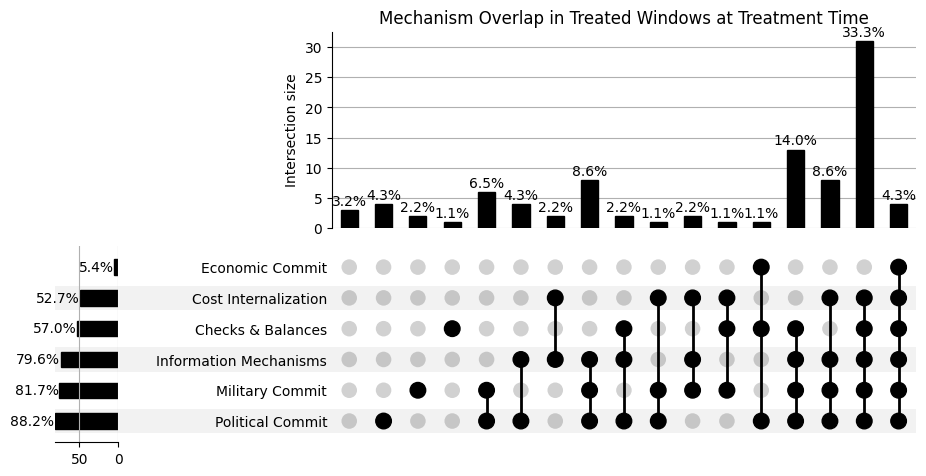

In [31]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
from upsetplot import UpSet
import matplotlib.pyplot as plt

# Solo una fila por treated window en t=0
df0 = df_clean[(df_clean['is_treated_window']==1) & (df_clean['window_t']==0)]
df0 = df0.drop_duplicates(subset=['window_id'])

mecha_cols = [
    'has_info_mecha',
    'has_commit_pol_mecha',
    'has_commit_econ_mecha',
    'has_commit_mil_mecha',
    'has_cost_mecha',
    'has_balancing_mecha'
]

label_map = {
    'has_info_mecha': 'Information Mechanisms',
    'has_commit_pol_mecha': 'Political Commit',
    'has_commit_econ_mecha': 'Economic Commit',
    'has_commit_mil_mecha': 'Military Commit',
    'has_cost_mecha': 'Cost Internalization',
    'has_balancing_mecha': 'Checks & Balances'
}

# Creamos MultiIndex booleano
df_upset = df0.set_index(mecha_cols)['window_id'].notnull()

# Renombrar niveles del MtiIndex
df_upset.index = df_upset.index.rename(
    [label_map[col] for col in mecha_cols]
)
#df_upset = df0.set_index(mecha_cols)['window_id'].notnull()

plt.figure(figsize=(12,6))
UpSet(df_upset, subset_size='count', show_percentages=True).plot()
plt.title("Mechanism Overlap in Treated Windows at Treatment Time")
plt.show()
